<a href="https://colab.research.google.com/github/jake-whipp/FER/blob/main/DeepLearning_FER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup

### Imports

Import the necessary libraries to handle navigating the filesystem and accessing the images in the data folder. Numpy will be used for numerical operations and pyplot to plot the results.

In [ ]:
import os
import copy
import random
import shutil
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

Import the relevant PyTorch and torchvision libraries for transfer learning, dataset handling and EfficientNet classification.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models, transforms
from torchvision.datasets import ImageFolder

To produce metrics about the result, such as a confusion matrix and classification report, import the following:

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

### Mounting

Mount and access Google drive, which hosts the files for the JAFFE and CK+ dataset images (for both training and testing). Seed the random number generators for each library with an arbitrary value

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/Colab\ Notebooks/AI/Assignment\ 2/
%pwd

SEED = 76
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/AI/Assignment 2


# Model

### Face Detection

Firstly, load `haarcascade_frontalface_default.xml` for face detection. This is a pre-trained face detection model used by OpenCV, trained using Haar-like features (patterns of contrast).

In [ ]:
haarcascade_path = "./haarcascade_frontalface_default.xml"
face_cascade = cv2.CascadeClassifier(haarcascade_path)

Now create a function which will load each image from the original dataset folder, detect and crop the face, and then save that processed face into a new folder structure that `ImageFolder` can read directly.

It assumes that the source folder is divided into subfolders of each emotion type (happiness, sadness, etc.) - these are the "labels" for each image.

Because `ImageFolder` expects images to be stored on disk inside class subfolders, the cropped faces will be written into temporary processed folders for CK+ and JAFFE. If no face is detected, the full image will be kept as a fallback so that no sample is lost .

In [ ]:
def load_and_crop_faces(source_root, destination_root):
    if os.path.exists(destination_root):
        shutil.rmtree(destination_root)

    os.makedirs(destination_root, exist_ok=True)
    saved_count = 0

    # Loop through all subfolders in the source path
    for label in sorted(os.listdir(source_root)):
        label_source_path = os.path.join(source_root, label)

        # label = happiness, sadness, etc.
        if not os.path.isdir(label_source_path):
            continue

        label_destination_path = os.path.join(destination_root, label)
        os.makedirs(label_destination_path, exist_ok=True)

        for img_file in sorted(os.listdir(label_source_path)):
            img_path = os.path.join(label_source_path, img_file)

            # Read the image in greyscale because both datasets are prepared in greyscale
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            # Skip any empty or broken image files
            if img is None:
                continue

            # Detect the face in the image
            faces = face_cascade.detectMultiScale(
                img,
                scaleFactor=1.1,
                minNeighbors=5,
                minSize=(30, 30)
            )

            if len(faces) > 0:
                # Use the largest detected face if multiple are found
                x, y, w, h = max(faces, key=lambda coords: coords[2] * coords[3])
                cropped_face = img[y:y + h, x:x + w]
            else:
                # Fallback, keep the full image if no face is detected
                cropped_face = img

            # Save as RGB so that EfficientNet can later receive 3channel input
            processed_image = Image.fromarray(cropped_face).convert("RGB")
            output_name = f"{os.path.splitext(img_file)[0]}.png"
            output_path = os.path.join(label_destination_path, output_name)
            processed_image.save(output_path)

            saved_count += 1

    return saved_count

def count_saved_images(folder_path):
    total_images = 0

    for label in sorted(os.listdir(folder_path)):
        label_path = os.path.join(folder_path, label)

        if not os.path.isdir(label_path):
            continue

        total_images += len([
            file_name for file_name in os.listdir(label_path)
            if os.path.isfile(os.path.join(label_path, file_name))
        ])

    return total_images

Now this function can be applied to both datasets and both splits.


In [ ]:
# Original dataset folders
CK_train_folder_path = "./CK/Converted/Training"
CK_test_folder_path = "./CK/Converted/Test"

JAFFE_train_folder_path = "./JAFFE/Converted/Training"
JAFFE_test_folder_path = "./JAFFE/Converted/Test"

# Processed faces folder
PROCESSED_ROOT = "./Processed_Faces"

CK_train_processed_path = os.path.join(PROCESSED_ROOT, "CK", "Training")
CK_test_processed_path = os.path.join(PROCESSED_ROOT, "CK", "Test")

JAFFE_train_processed_path = os.path.join(PROCESSED_ROOT, "JAFFE", "Training")
JAFFE_test_processed_path = os.path.join(PROCESSED_ROOT, "JAFFE", "Test")

# Create cropped face folders for each split
load_and_crop_faces(CK_train_folder_path, CK_train_processed_path)
load_and_crop_faces(CK_test_folder_path, CK_test_processed_path)

load_and_crop_faces(JAFFE_train_folder_path, JAFFE_train_processed_path)
load_and_crop_faces(JAFFE_test_folder_path, JAFFE_test_processed_path)

print(f"CK+ Train Images: {count_saved_images(CK_train_processed_path)}")
print(f"CK+ Test Images: {count_saved_images(CK_test_processed_path)}")
print(f"JAFFE Train Images: {count_saved_images(JAFFE_train_processed_path)}")
print(f"JAFFE Test Images: {count_saved_images(JAFFE_test_processed_path)}")

CK+ Train Images: 228
CK+ Test Images: 97
JAFFE Train Images: 126
JAFFE Test Images: 58


### Feature Extraction

Unlike HOG and LBP from assignment 1, EfficientNet learns the relevant feature hierarchies automatically from the image data itself.

Therefore the main feature extraction stage here is to consistently prepare each face before it enters the network.

*   Each cropped face will be resized to `224x224`, which is suitable for EfficientNet.
*   The training data will be lightly augmented to help the model generalise better on a small dataset.
*   These augmentations do create new image variations during training (for example flipped or slightly rotated faces), even though they are generated on-the-fly rather than being permanently written to disk.
*   The images will also be normalised to the standard ImageNet distribution expected by the pre-trained EfficientNet base model/ "backbone".

In [ ]:
IMAGE_SIZE = 224
BATCH_SIZE = 16

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
print("CK+ processed training path:", CK_train_processed_path)
print("CK+ processed test path:", CK_test_processed_path)
print("JAFFE processed training path:", JAFFE_train_processed_path)
print("JAFFE processed test path:", JAFFE_test_processed_path)

CK+ processed training path: ./Processed_Faces/CK/Training
CK+ processed test path: ./Processed_Faces/CK/Test
JAFFE processed training path: ./Processed_Faces/JAFFE/Training
JAFFE processed test path: ./Processed_Faces/JAFFE/Test


### Classification

`ImageFolder` assigns each class folder an integer. For example:

*   `Anger` --> `0`
*   `Happiness` --> `1`

etc.

A shared class integer order will be checked across CK+ and JAFFE to make sure that both datasets are interpreted in the same way.

In [ ]:
# Build datasets
CK_train_dataset = ImageFolder(CK_train_processed_path, train_transform)
CK_test_dataset = ImageFolder(CK_test_processed_path, test_transform)

JAFFE_train_dataset = ImageFolder(JAFFE_train_processed_path, train_transform)
JAFFE_test_dataset = ImageFolder(JAFFE_test_processed_path, test_transform)

# Ensure that all datasets use the same class ordering
all_dataset_classes_match = (
    CK_train_dataset.classes == CK_test_dataset.classes ==
    JAFFE_train_dataset.classes == JAFFE_test_dataset.classes
)

if not all_dataset_classes_match:
    raise Exception("The class folders are not matching across the CK+ and JAFFE datasets.")

emotion_classes = CK_train_dataset.classes

print("Emotion Label Mapping:")
for emotion, index in CK_train_dataset.class_to_idx.items():
    print(f"{emotion} --> {index}")

Emotion Label Mapping:
Anger --> 0
Fear --> 1
Happiness --> 2
Neutral --> 3
Sadness --> 4
Surprise --> 5


Because deep learning models are sensitive to the scale of the input, image normalisation must be applied so that each channel follows the distribution expected by the pre-trained EfficientNet backbone.

As well as this, CK+ can still present class imbalance. Therefore, DataLoaders and class weights will also be prepared so that under-represented emotions can contribute more during training.

In [ ]:
def build_class_weights(dataset):
    class_counts = np.bincount(dataset.targets, minlength=len(dataset.classes))

    # Inverse frequency weighting
    class_weights = len(dataset.targets) / (len(dataset.classes) * np.maximum(class_counts, 1))
    return torch.tensor(class_weights, dtype=torch.float32)

# Build DataLoaders
CK_train_loader = DataLoader(CK_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
CK_test_loader = DataLoader(CK_test_dataset, batch_size=BATCH_SIZE, shuffle=False)

JAFFE_train_loader = DataLoader(JAFFE_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
JAFFE_test_loader = DataLoader(JAFFE_test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Build class weights for each training set
CK_class_weights = build_class_weights(CK_train_dataset)
JAFFE_class_weights = build_class_weights(JAFFE_train_dataset)

print("CK+ class weights:", CK_class_weights)
print("JAFFE class weights:", JAFFE_class_weights)

CK+ class weights: tensor([1.2258, 2.1111, 0.7917, 0.7170, 1.9000, 0.6552])
JAFFE class weights: tensor([1.0000, 0.9545, 1.0000, 0.9545, 1.1053, 1.0000])


Now the EfficientNet-B0 classifier can be trained using transfer learning.

The convolutional backbone will be frozen initially so that the new classification layer can adapt first. After that, the backbone will be unfrozen and fine-tuned with a smaller learning rate.

It will be fit and tested on CK+ data, and then JAFFE. The results will be recorded for each.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD = np.array([0.229, 0.224, 0.225])

def create_efficientnet_b0_model(num_classes):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

    # Freeze the basemodel/backbone for the first stage of transfer learning
    for param in model.features.parameters():
        param.requires_grad = False

    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, num_classes)
    )

    return model

def train_model(model, train_loader, test_loader, class_weights, num_epochs=20, freeze_epochs=5,
                classifier_lr=1e-3, fine_tune_lr=1e-4):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=classifier_lr)

    history = {
        "train_loss": [],
        "test_loss": [],
        "train_acc": [],
        "test_acc": []
    }

    best_state = copy.deepcopy(model.state_dict())
    best_test_acc = 0.0

    for epoch in range(num_epochs):
        if epoch == freeze_epochs:
            # Unfreeze the backbone and continue fine-tuning at a lower learning rate
            for param in model.features.parameters():
                param.requires_grad = True

            optimizer = optim.Adam(model.parameters(), lr=fine_tune_lr)
            print("Backbone unfrozen for finetuning.")

        # Training pass
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = correct_train / total_train

        # Evaluation pass
        model.eval()
        running_test_loss = 0.0
        correct_test = 0
        total_test = 0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                running_test_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total_test += labels.size(0)
                correct_test += (predicted == labels).sum().item()

        test_loss = running_test_loss / len(test_loader)
        test_acc = correct_test / total_test

        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)

        if test_acc >= best_test_acc:
            best_test_acc = test_acc
            best_state = copy.deepcopy(model.state_dict())

        print(
            f"Epoch [{epoch + 1}/{num_epochs}] | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}"
        )

    model.load_state_dict(best_state)
    return model, history

def evaluate_model(model, data_loader):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    return np.array(y_true), np.array(y_pred)

def plot_training_history(history, dataset_name):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(10, 5))
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["test_acc"], label="Test Accuracy")
    plt.title(f"{dataset_name} Accuracy per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["test_loss"], label="Test Loss")
    plt.title(f"{dataset_name} Loss per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

def denormalise_image(image_tensor):
    image = image_tensor.cpu().numpy().transpose(1, 2, 0)
    image = (image * IMAGENET_STD) + IMAGENET_MEAN
    return np.clip(image, 0, 1)

def get_prediction_examples(model, data_loader, class_names, num_examples=3):
    model.eval()
    examples_by_prediction = {}

    with torch.no_grad():
        for images, labels in data_loader:
            outputs = model(images.to(device))
            predictions = torch.argmax(outputs, dim=1).cpu()

            for image, true_label, predicted_label in zip(images, labels, predictions):
                predicted_index = predicted_label.item()

                example = {
                    "image": image,
                    "true_label": class_names[true_label.item()],
                    "predicted_label": class_names[predicted_index]
                }

                if predicted_index not in examples_by_prediction:
                    examples_by_prediction[predicted_index] = []

                examples_by_prediction[predicted_index].append(example)

    # Pick one random example for each predicted class
    collected_examples = [
        random.choice(examples)
        for examples in examples_by_prediction.values()
    ]

    # Then randomly choose up to num_examples from those
    return random.sample(
        collected_examples,
        k=min(num_examples, len(collected_examples))
    )

def plot_example_classifications(example_groups):
    rows = len(example_groups)
    cols = 3

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4.5 * rows))

    if rows == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_index, group in enumerate(example_groups):
        examples = group["examples"]

        for col_index in range(cols):
            ax = axes[row_index, col_index]

            if col_index < len(examples):
                example = examples[col_index]
                ax.imshow(denormalise_image(example["image"]))
                ax.set_title(
                    f"{group['dataset_name']}\n"
                    f"True: {example['true_label']}\n"
                    f"Pred: {example['predicted_label']}"
                )
            else:
                ax.set_title(f"{group['dataset_name']}\nNo further distinct prediction found")

            ax.axis("off")

    fig.suptitle("Example FER classifications with three different predicted emotions", fontsize=14)
    plt.tight_layout()
    plt.show()

Using device: cuda


Starting with CK+:

In [ ]:
# Train on CK+ dataset
CK_model = create_efficientnet_b0_model(num_classes=len(emotion_classes))
CK_model, CK_history = train_model(
    CK_model,
    CK_train_loader,
    CK_test_loader,
    CK_class_weights,
    num_epochs=20,
    freeze_epochs=5
)

# Predict on CK+ test set
CK_y_true, CK_y_pred = evaluate_model(CK_model, CK_test_loader)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 120MB/s] 


Epoch [1/20] | Train Loss: 1.8079 | Train Acc: 0.1711 | Test Loss: 1.6116 | Test Acc: 0.3608
Epoch [2/20] | Train Loss: 1.6171 | Train Acc: 0.5044 | Test Loss: 1.5569 | Test Acc: 0.3814
Epoch [3/20] | Train Loss: 1.5214 | Train Acc: 0.5439 | Test Loss: 1.5141 | Test Acc: 0.4433
Epoch [4/20] | Train Loss: 1.4437 | Train Acc: 0.6228 | Test Loss: 1.4148 | Test Acc: 0.5567
Epoch [5/20] | Train Loss: 1.3038 | Train Acc: 0.6667 | Test Loss: 1.3372 | Test Acc: 0.6186
Backbone unfrozen for finetuning.
Epoch [6/20] | Train Loss: 1.2082 | Train Acc: 0.7149 | Test Loss: 1.0149 | Test Acc: 0.7113
Epoch [7/20] | Train Loss: 0.9074 | Train Acc: 0.7939 | Test Loss: 0.8007 | Test Acc: 0.7629
Epoch [8/20] | Train Loss: 0.7788 | Train Acc: 0.7939 | Test Loss: 0.6485 | Test Acc: 0.8144
Epoch [9/20] | Train Loss: 0.6396 | Train Acc: 0.8904 | Test Loss: 0.5570 | Test Acc: 0.8144
Epoch [10/20] | Train Loss: 0.5110 | Train Acc: 0.8860 | Test Loss: 0.4552 | Test Acc: 0.8763
Epoch [11/20] | Train Loss: 0.3803 

Then JAFFE:

In [ ]:
# Train on JAFFE dataset
JAFFE_model = create_efficientnet_b0_model(num_classes=len(emotion_classes))
JAFFE_model, JAFFE_history = train_model(
    JAFFE_model,
    JAFFE_train_loader,
    JAFFE_test_loader,
    JAFFE_class_weights,
    num_epochs=20,
    freeze_epochs=5
)

# Predict on JAFFE test set
JAFFE_y_true, JAFFE_y_pred = evaluate_model(JAFFE_model, JAFFE_test_loader)

Epoch [1/20] | Train Loss: 1.8391 | Train Acc: 0.1190 | Test Loss: 1.7538 | Test Acc: 0.2069
Epoch [2/20] | Train Loss: 1.7612 | Train Acc: 0.2540 | Test Loss: 1.7170 | Test Acc: 0.2931
Epoch [3/20] | Train Loss: 1.6726 | Train Acc: 0.3651 | Test Loss: 1.6940 | Test Acc: 0.2931
Epoch [4/20] | Train Loss: 1.6373 | Train Acc: 0.3810 | Test Loss: 1.6947 | Test Acc: 0.2931
Epoch [5/20] | Train Loss: 1.5350 | Train Acc: 0.5317 | Test Loss: 1.7040 | Test Acc: 0.2759
Backbone unfrozen for finetuning.
Epoch [6/20] | Train Loss: 1.4676 | Train Acc: 0.5635 | Test Loss: 1.5522 | Test Acc: 0.4828
Epoch [7/20] | Train Loss: 1.3433 | Train Acc: 0.6508 | Test Loss: 1.4177 | Test Acc: 0.4655
Epoch [8/20] | Train Loss: 1.2205 | Train Acc: 0.6429 | Test Loss: 1.2888 | Test Acc: 0.4655
Epoch [9/20] | Train Loss: 1.1248 | Train Acc: 0.7222 | Test Loss: 1.2058 | Test Acc: 0.5690
Epoch [10/20] | Train Loss: 0.9834 | Train Acc: 0.7619 | Test Loss: 1.0912 | Test Acc: 0.6207
Epoch [11/20] | Train Loss: 0.8672 

# Results


### Confusion Matrix

A confusion matrix is a table that summarises the performance of the classification model by comparing the model’s predicted labels/emotions with the true labels.

Each row represents the actual emotion, and each column represents the predicted emotion made by the classifier. The quantity in each cell is the number of guesses made by the model.

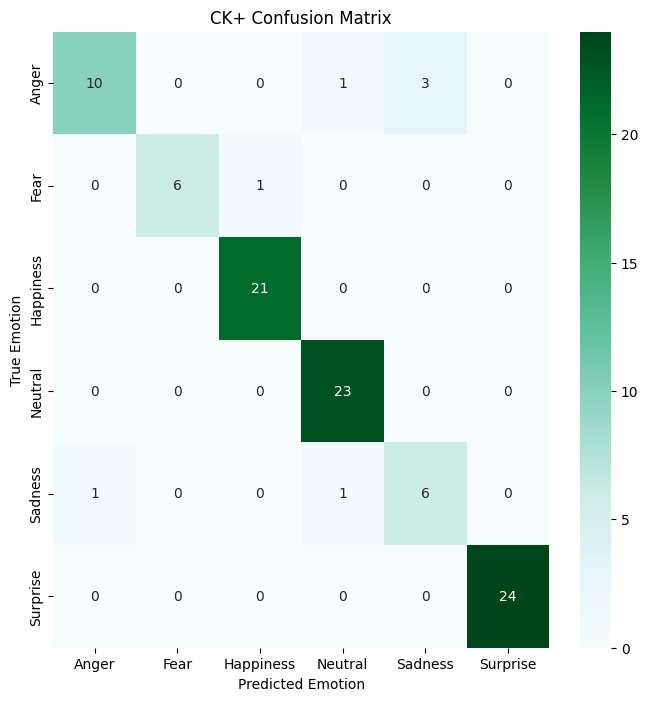

In [ ]:
# CK+ Confusion Matrix
CK_conf_matrix = confusion_matrix(CK_y_true, CK_y_pred)

plt.figure(figsize=(8, 8))
sns.heatmap(
    CK_conf_matrix,
    annot=True,
    fmt="d",
    cmap="BuGn",
    xticklabels=emotion_classes,
    yticklabels=emotion_classes
)
plt.title("CK+ Confusion Matrix")
plt.ylabel("True Emotion")
plt.xlabel("Predicted Emotion")
plt.show()

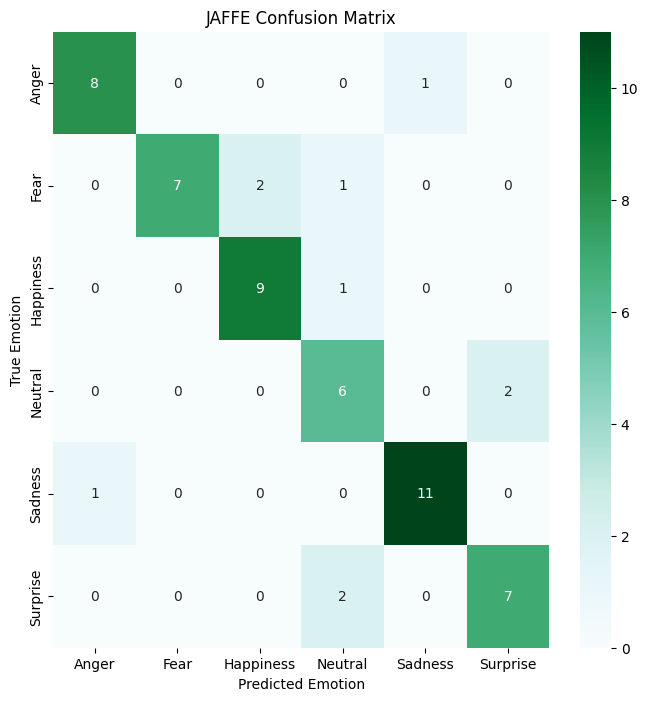

In [ ]:
# JAFFE Confusion Matrix
JAFFE_conf_matrix = confusion_matrix(JAFFE_y_true, JAFFE_y_pred)

plt.figure(figsize=(8, 8))
sns.heatmap(
    JAFFE_conf_matrix,
    annot=True,
    fmt="d",
    cmap="BuGn",
    xticklabels=emotion_classes,
    yticklabels=emotion_classes
)
plt.title("JAFFE Confusion Matrix")
plt.ylabel("True Emotion")
plt.xlabel("Predicted Emotion")
plt.show()

### Normalised Confusion Matrix

A normalised confusion matrix presents the percentage of guesses for each cell, rather than the raw number of guesses. This way, the colour grading of the heatmap represents the proportion and distribution of guesses as opposed to just the raw amount.

This prevents emotions with less samples in the dataset from losing their colour in the matrix automatically. As a result, it makes accurate and inaccurate guesses more visible and clear.

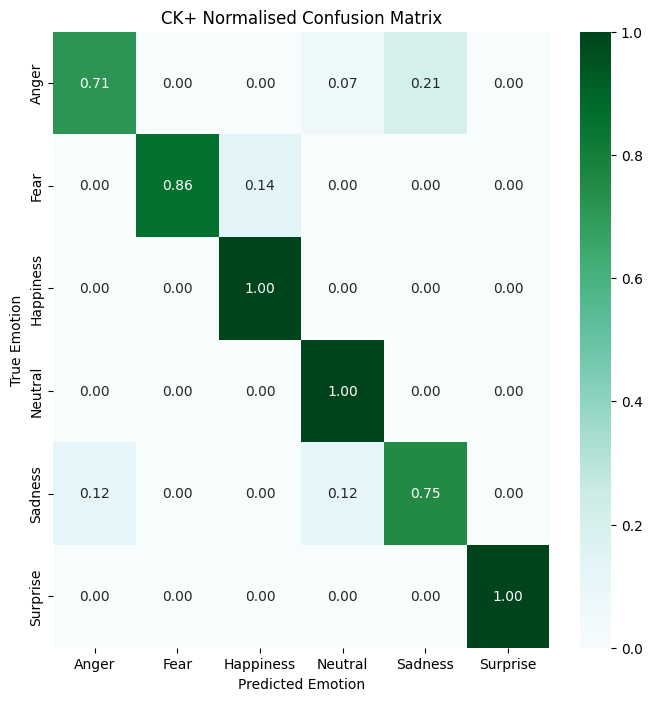

In [ ]:
# Normalised CK+ Confusion Matrix
CK_conf_matrix_norm = confusion_matrix(
    CK_y_true, CK_y_pred, normalize='true'
)

plt.figure(figsize=(8, 8))
sns.heatmap(
    CK_conf_matrix_norm,
    annot=True,
    fmt=".2f",
    cmap="BuGn",
    xticklabels=emotion_classes,
    yticklabels=emotion_classes
)
plt.title("CK+ Normalised Confusion Matrix")
plt.ylabel("True Emotion")
plt.xlabel("Predicted Emotion")
plt.show()

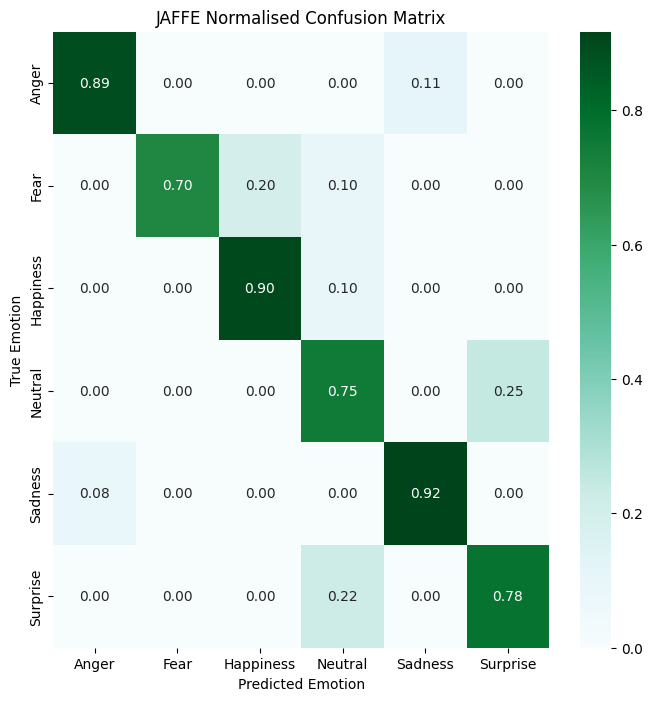

In [ ]:
# Normalised JAFFE Confusion Matrix
JAFFE_conf_matrix_norm = confusion_matrix(
    JAFFE_y_true, JAFFE_y_pred, normalize='true'
)

plt.figure(figsize=(8, 8))
sns.heatmap(
    JAFFE_conf_matrix_norm,
    annot=True,
    fmt=".2f",
    cmap="BuGn",
    xticklabels=emotion_classes,
    yticklabels=emotion_classes
)
plt.title("JAFFE Normalised Confusion Matrix")
plt.ylabel("True Emotion")
plt.xlabel("Predicted Emotion")
plt.show()

### Training/Testing Accuracy

The training/testing accuracy provides both a final summary score and an epoch-by-epoch view of how well the model learned on each dataset.

CK+ Test Accuracy: 0.9278
JAFFE Test Accuracy: 0.8276


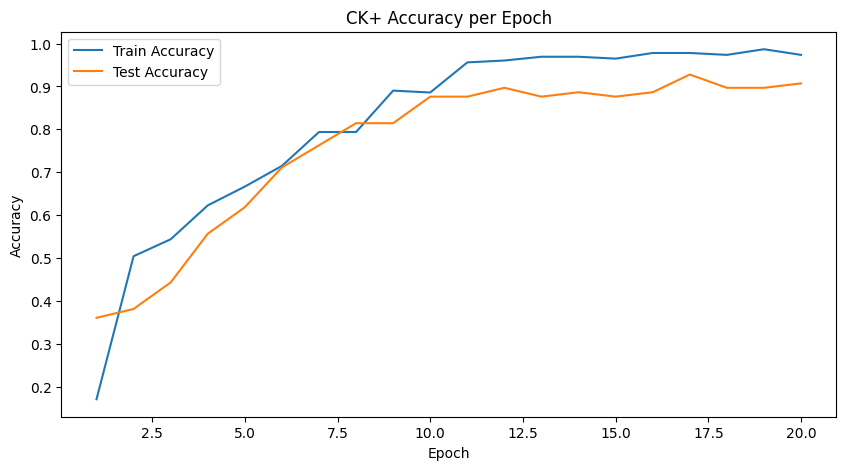

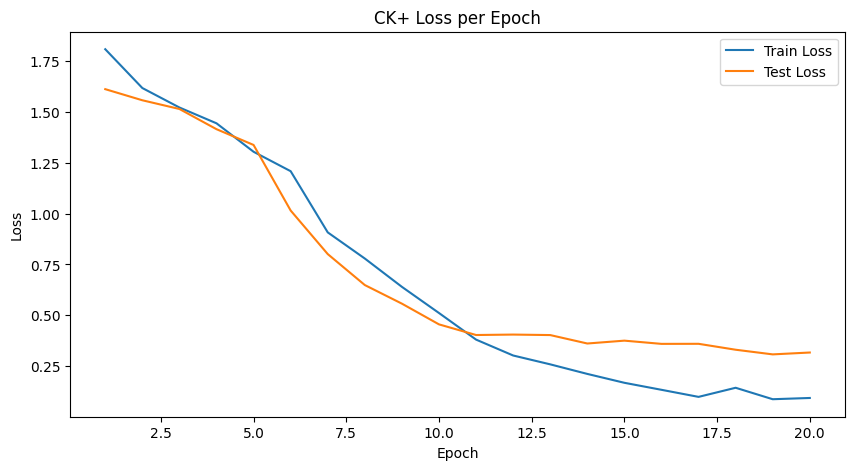

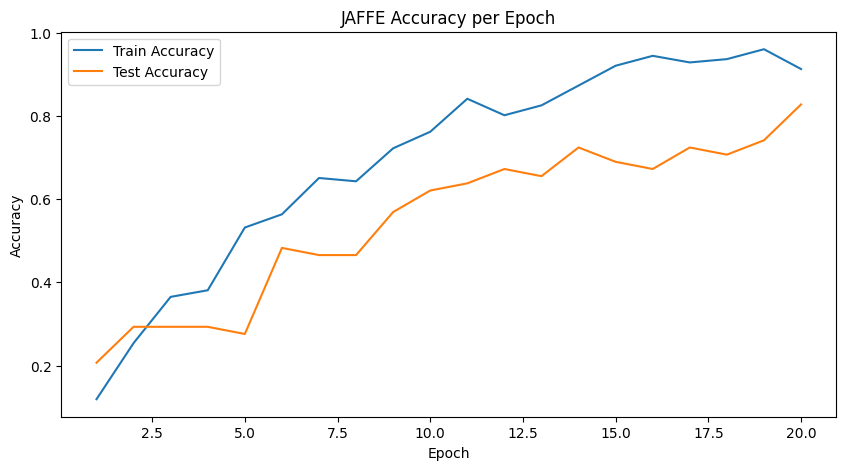

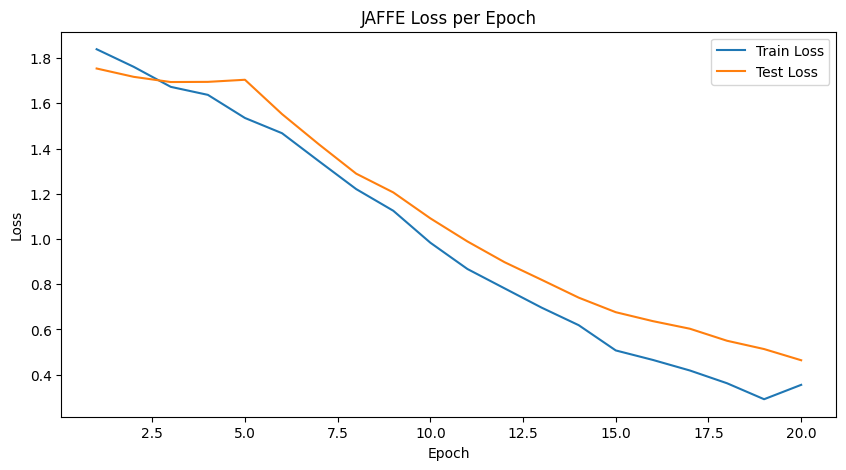

In [ ]:
CK_accuracy = accuracy_score(CK_y_true, CK_y_pred)
print(f"CK+ Test Accuracy: {CK_accuracy:.4f}")

JAFFE_accuracy = accuracy_score(JAFFE_y_true, JAFFE_y_pred)
print(f"JAFFE Test Accuracy: {JAFFE_accuracy:.4f}")

plot_training_history(CK_history, "CK+")
plot_training_history(JAFFE_history, "JAFFE")

### Classification Report

The classification report provides some unique insight over the other results.

*   Precision rating = the proportion of correct predictions out of *all predictions* made for that class
*   Recall rating = the proportion of correct guesses out of the total number of *samples* for that class

The f1-score in particular gives unique insight because it combines precision and recall with a harmonic mean.

In [ ]:
print("CK+ Classification Report:")
print(classification_report(CK_y_true, CK_y_pred, target_names=emotion_classes))

print("JAFFE Classification Report:")
print(classification_report(JAFFE_y_true, JAFFE_y_pred, target_names=emotion_classes))

CK+ Classification Report:
              precision    recall  f1-score   support

       Anger       0.91      0.71      0.80        14
        Fear       1.00      0.86      0.92         7
   Happiness       0.95      1.00      0.98        21
     Neutral       0.92      1.00      0.96        23
     Sadness       0.67      0.75      0.71         8
    Surprise       1.00      1.00      1.00        24

    accuracy                           0.93        97
   macro avg       0.91      0.89      0.89        97
weighted avg       0.93      0.93      0.93        97

JAFFE Classification Report:
              precision    recall  f1-score   support

       Anger       0.89      0.89      0.89         9
        Fear       1.00      0.70      0.82        10
   Happiness       0.82      0.90      0.86        10
     Neutral       0.60      0.75      0.67         8
     Sadness       0.92      0.92      0.92        12
    Surprise       0.78      0.78      0.78         9

    accuracy         

### Example Classifications

The figure below provides example classifications from the test sets.

To make this more informative than showing three random images, the examples are selected so that the model predicts three different emotions where possible. This gives a clearer visual indication of how the classifier responds to different expressions.

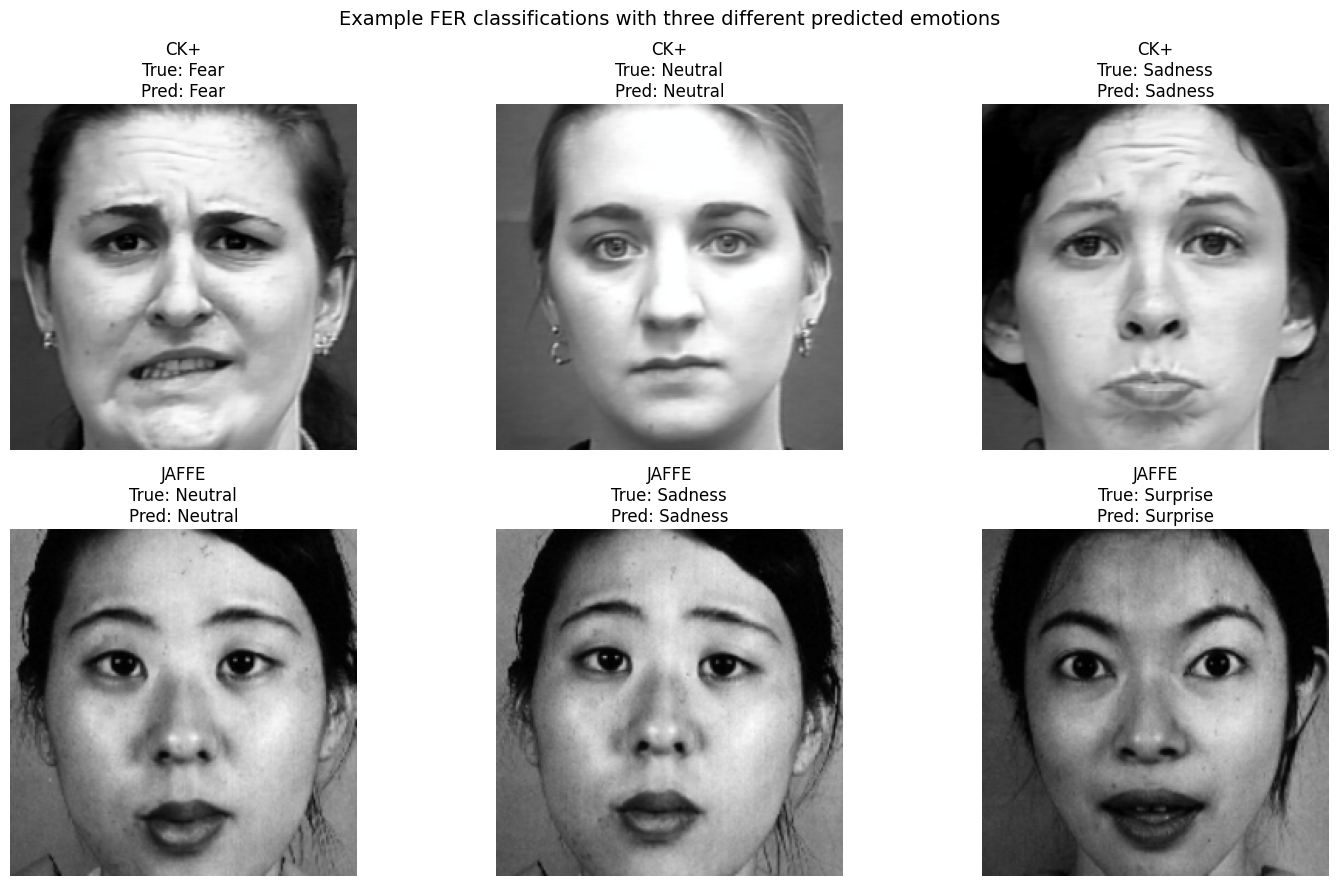

In [ ]:
CK_example_group = {
    "dataset_name": "CK+",
    "examples": get_prediction_examples(
        CK_model,
        CK_test_loader,
        emotion_classes,
        num_examples=3
    )
}

JAFFE_example_group = {
    "dataset_name": "JAFFE",
    "examples": get_prediction_examples(
        JAFFE_model,
        JAFFE_test_loader,
        emotion_classes,
        num_examples=3
    )
}

plot_example_classifications([CK_example_group, JAFFE_example_group])